<a href="https://colab.research.google.com/github/Tapopita/Desafio-2-Analisis-de-evacion-de-clientes-Carlos-Aravena-N/blob/main/Desafio_2_An%C3%A1lisis_de_evacion_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 Extracción

In [8]:
import pandas as pd
import json

# Ruta del archivo en Colab
ruta = "/content/TelecomX_Data.json"

# Abrir archivo JSON
with open(ruta, "r", encoding="utf-8") as archivo:
    data = json.load(archivo)

# Normalizar JSON a DataFrame
df = pd.json_normalize(data)

# Vista inicial
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



🔧 Transformación

In [9]:
# Copia de trabajo
df = df.copy()

# Renombrar columnas según diccionario
df = df.rename(columns={
    "customer.customerID": "customerID",
    "customer.gender": "gender",
    "customer.SeniorCitizen": "SeniorCitizen",
    "customer.Partner": "Partner",
    "customer.Dependents": "Dependents",
    "customer.tenure": "tenure",
    "phone.PhoneService": "PhoneService",
    "phone.MultipleLines": "MultipleLines",
    "internet.InternetService": "InternetService",
    "internet.OnlineSecurity": "OnlineSecurity",
    "internet.OnlineBackup": "OnlineBackup",
    "internet.DeviceProtection": "DeviceProtection",
    "internet.TechSupport": "TechSupport",
    "internet.StreamingTV": "StreamingTV",
    "internet.StreamingMovies": "StreamingMovies",
    "account.Contract": "Contract",
    "account.PaperlessBilling": "PaperlessBilling",
    "account.PaymentMethod": "PaymentMethod",
    "account.Charges.Monthly": "Charges.Monthly",
    "account.Charges.Total": "Charges.Total",
    "Churn": "Churn"
})

# Verificar columnas después del renombrado
print("Columnas renombradas:")
print(df.columns.tolist())

# Revisar tipos y nulos iniciales
print("\nInformación general:")
print(df.info())

print("\nValores nulos por columna:")
print(df.isnull().sum())

# Convertir Charges.Total a numérico
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")

# Convertir SeniorCitizen a categoría más legible
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})

# Estandarizar texto en columnas categóricas
columnas_texto = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "Churn"
]

for col in columnas_texto:
    df[col] = df[col].astype(str).str.strip()

# Revisar valores vacíos como texto
print("\nValores vacíos por columna:")
print((df == "").sum())

# Eliminar nulos
df = df.dropna()

# Verificación final
print("\nDimensiones finales del dataset:")
print(df.shape)

print("\nTipos de datos finales:")
print(df.dtypes)

print("\nValores nulos finales:")
print(df.isnull().sum())

Columnas renombradas:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   I

📊 Carga y análisis

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resumen general
print("Resumen estadístico variables numéricas:")
display(df[["tenure", "Charges.Monthly", "Charges.Total"]].describe())

Resumen estadístico variables numéricas:


,tenure,Charges.Monthly,Charges.Total
count,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213
std,24.558067,30.125739,2268.632997
min,1.000000,18.250000,18.800000
25%,9.000000,35.450000,400.225000
50%,29.000000,70.300000,1391.000000
75%,55.000000,89.900000,3785.300000
max,72.000000,118.750000,8684.800000


3.1 Distribución de churn

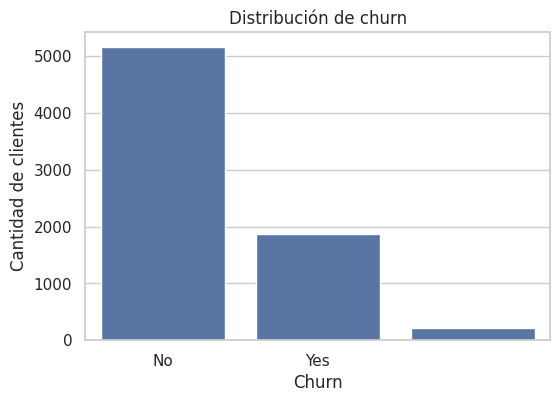

Porcentaje de churn:
Churn
No     71.154906
Yes    25.757993
        3.087100
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribución de churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

# Porcentaje de churn
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print("Porcentaje de churn:")
print(churn_pct)

3.2 Churn por género

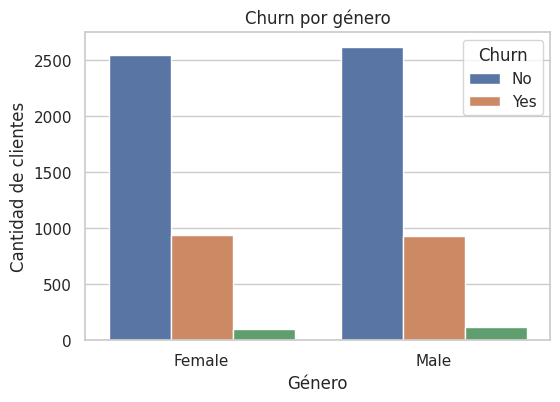

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Churn por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de clientes")
plt.show()

3.3 Churn por adulto mayor

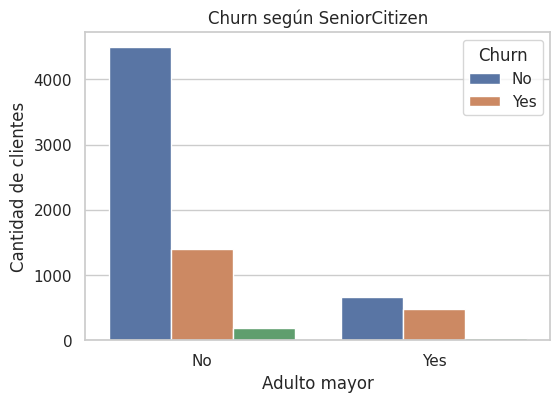

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn según SeniorCitizen")
plt.xlabel("Adulto mayor")
plt.ylabel("Cantidad de clientes")
plt.show()

3.4 Churn por tipo de contrato

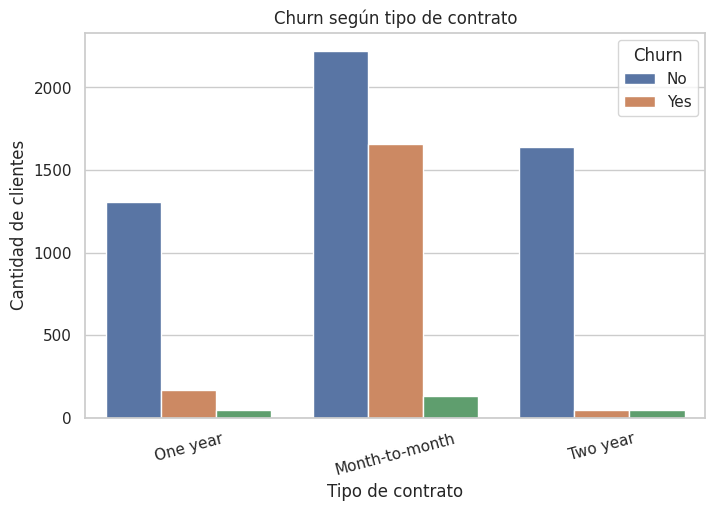

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=15)
plt.show()

3.5 Churn por método de pago

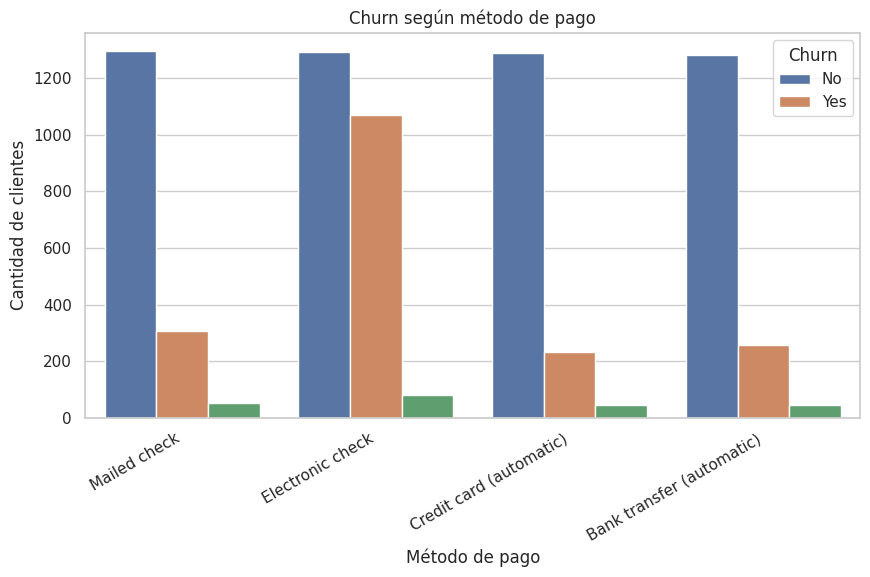

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=30, ha="right")
plt.show()

3.6 Antigüedad del cliente y churn

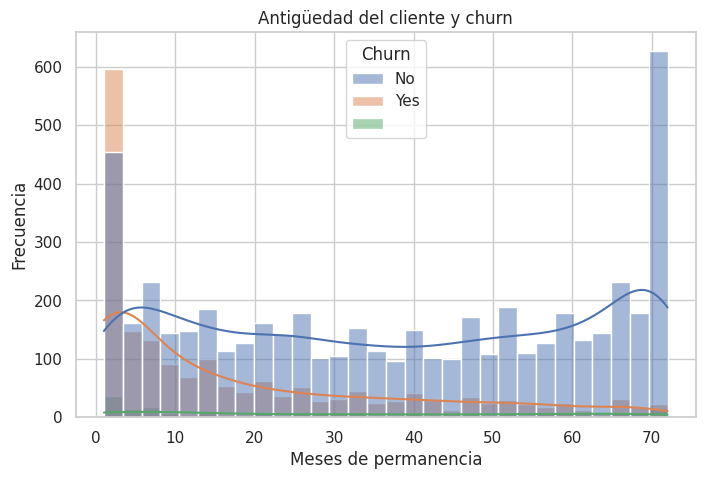

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Antigüedad del cliente y churn")
plt.xlabel("Meses de permanencia")
plt.ylabel("Frecuencia")
plt.show()

3.7 Cargos mensuales y churn

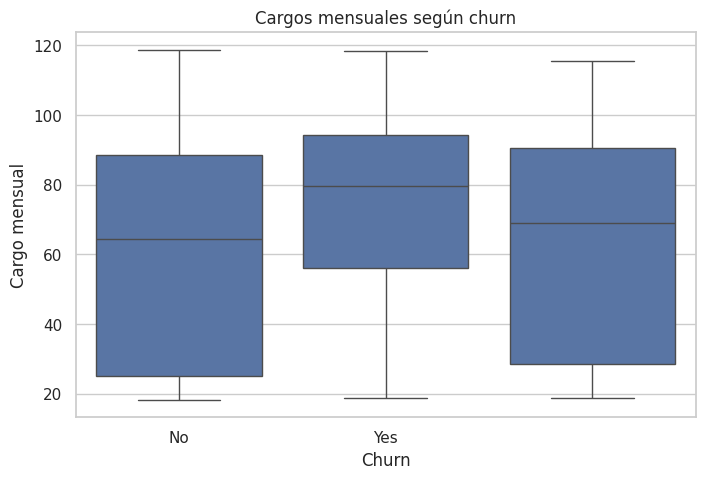

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="Charges.Monthly")
plt.title("Cargos mensuales según churn")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")
plt.show()

3.8 Cargos totales y churn

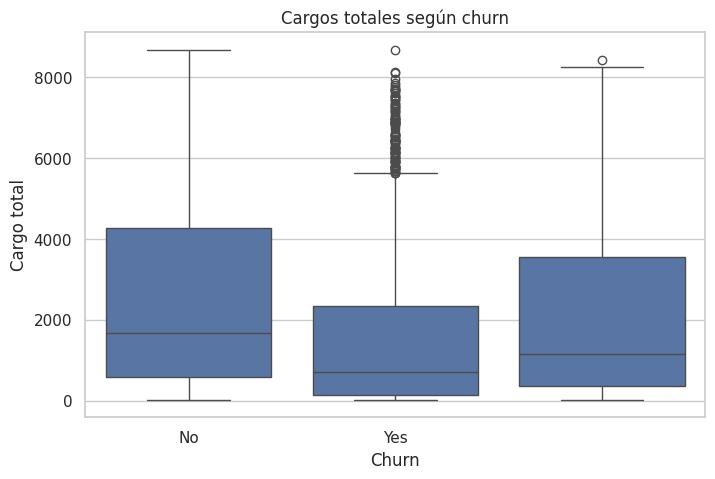

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="Charges.Total")
plt.title("Cargos totales según churn")
plt.xlabel("Churn")
plt.ylabel("Cargo total")
plt.show()

3.9 Servicios de internet y churn

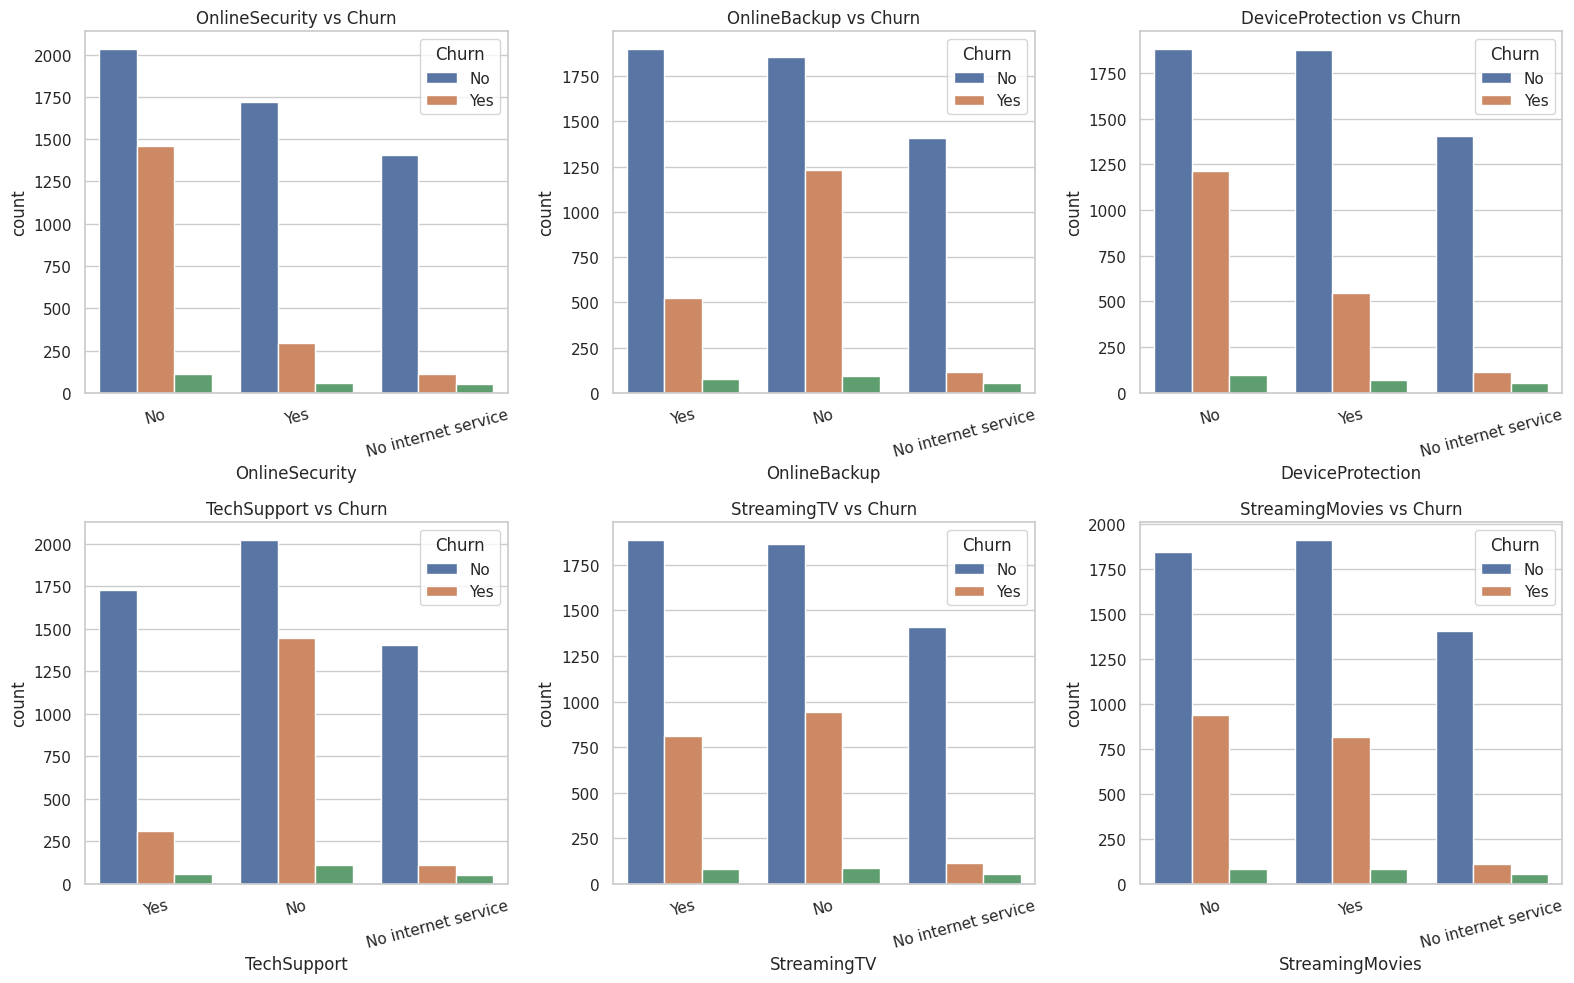

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))

sns.countplot(data=df, x="OnlineSecurity", hue="Churn", ax=axes[0,0])
axes[0,0].set_title("OnlineSecurity vs Churn")
axes[0,0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x="OnlineBackup", hue="Churn", ax=axes[0,1])
axes[0,1].set_title("OnlineBackup vs Churn")
axes[0,1].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x="DeviceProtection", hue="Churn", ax=axes[0,2])
axes[0,2].set_title("DeviceProtection vs Churn")
axes[0,2].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x="TechSupport", hue="Churn", ax=axes[1,0])
axes[1,0].set_title("TechSupport vs Churn")
axes[1,0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x="StreamingTV", hue="Churn", ax=axes[1,1])
axes[1,1].set_title("StreamingTV vs Churn")
axes[1,1].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x="StreamingMovies", hue="Churn", ax=axes[1,2])
axes[1,2].set_title("StreamingMovies vs Churn")
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

3.10 Matriz de correlación

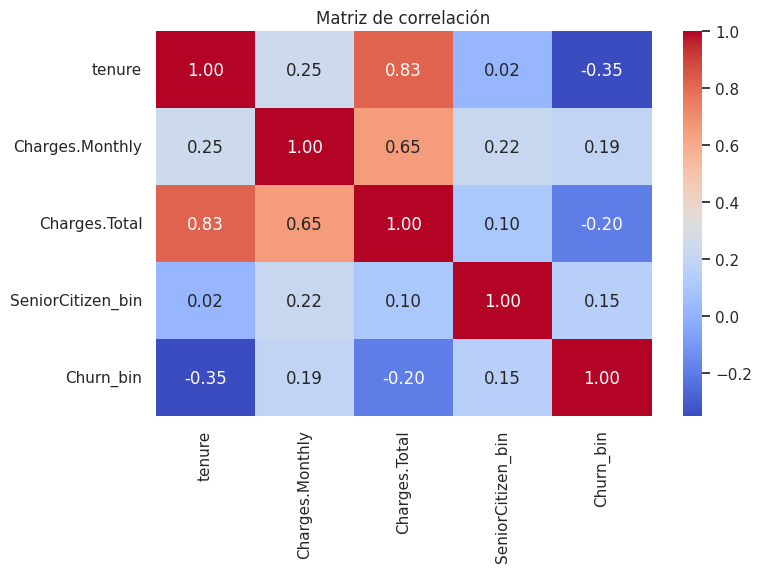

In [20]:
# Convertir churn a binario para correlación
df_corr = df.copy()
df_corr["Churn_bin"] = df_corr["Churn"].map({"Yes": 1, "No": 0})
df_corr["SeniorCitizen_bin"] = df_corr["SeniorCitizen"].map({"Yes": 1, "No": 0})

corr = df_corr[["tenure", "Charges.Monthly", "Charges.Total", "SeniorCitizen_bin", "Churn_bin"]].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

📄Informe final

In [23]:
informe = """
Informe final - Análisis de evasión de clientes en Telecom X

1. Objetivo
El objetivo de este análisis fue identificar patrones asociados a la evasión de clientes (churn) en Telecom X, a partir de un proceso de extracción, transformación, limpieza y análisis exploratorio de datos.

2. Principales hallazgos

a) Tipo de contrato
Se observó que los clientes con contrato mensual presentan una tasa de evasión significativamente mayor que aquellos con contratos de uno o dos años. Esto sugiere que la estabilidad contractual reduce la probabilidad de abandono.

b) Antigüedad del cliente
Los clientes con menor antigüedad (tenure) muestran mayor churn. Esto indica que los primeros meses de relación con la empresa son críticos y que la retención temprana debe ser una prioridad.

c) Cargos mensuales
Los clientes que abandonan la empresa tienden a presentar cargos mensuales más altos. Esto puede sugerir sensibilidad al precio, insatisfacción con la relación costo-beneficio o percepción de sobreprecio.

d) Servicios adicionales
Se detectó que los clientes que no cuentan con servicios como soporte técnico, seguridad en línea, respaldo o protección de dispositivos presentan mayores niveles de evasión. Estos servicios podrían estar aportando valor y ayudando a fidelizar.

e) Método de pago
Algunos métodos de pago muestran una mayor concentración de churn, lo que podría relacionarse con perfiles de clientes más propensos a cancelar o con fricciones en el proceso de pago.

3. Conclusión
La evasión de clientes en Telecom X no parece explicarse por un solo factor, sino por una combinación de variables comerciales y de comportamiento. Los factores más relevantes son:

- Contratos de corta duración
- Baja antigüedad del cliente
- Cargos mensuales altos
- Menor contratación de servicios complementarios

4. Recomendaciones
A partir de este análisis, se recomienda:

1. Diseñar estrategias de retención para clientes nuevos.
2. Incentivar contratos de mayor duración.
3. Revisar estructura de precios y percepción de valor.
4. Promover servicios adicionales como soporte técnico y seguridad.
5. Utilizar este dataset limpio como base para construir un modelo predictivo de churn.

En síntesis, el análisis exploratorio permitió detectar variables clave asociadas al abandono, dejando una base sólida para etapas posteriores de modelamiento predictivo y segmentación de clientes.
"""

print(informe)


Informe final - Análisis de evasión de clientes en Telecom X

1. Objetivo
El objetivo de este análisis fue identificar patrones asociados a la evasión de clientes (churn) en Telecom X, a partir de un proceso de extracción, transformación, limpieza y análisis exploratorio de datos.

2. Principales hallazgos

a) Tipo de contrato
Se observó que los clientes con contrato mensual presentan una tasa de evasión significativamente mayor que aquellos con contratos de uno o dos años. Esto sugiere que la estabilidad contractual reduce la probabilidad de abandono.

b) Antigüedad del cliente
Los clientes con menor antigüedad (tenure) muestran mayor churn. Esto indica que los primeros meses de relación con la empresa son críticos y que la retención temprana debe ser una prioridad.

c) Cargos mensuales
Los clientes que abandonan la empresa tienden a presentar cargos mensuales más altos. Esto puede sugerir sensibilidad al precio, insatisfacción con la relación costo-beneficio o percepción de sobrepre